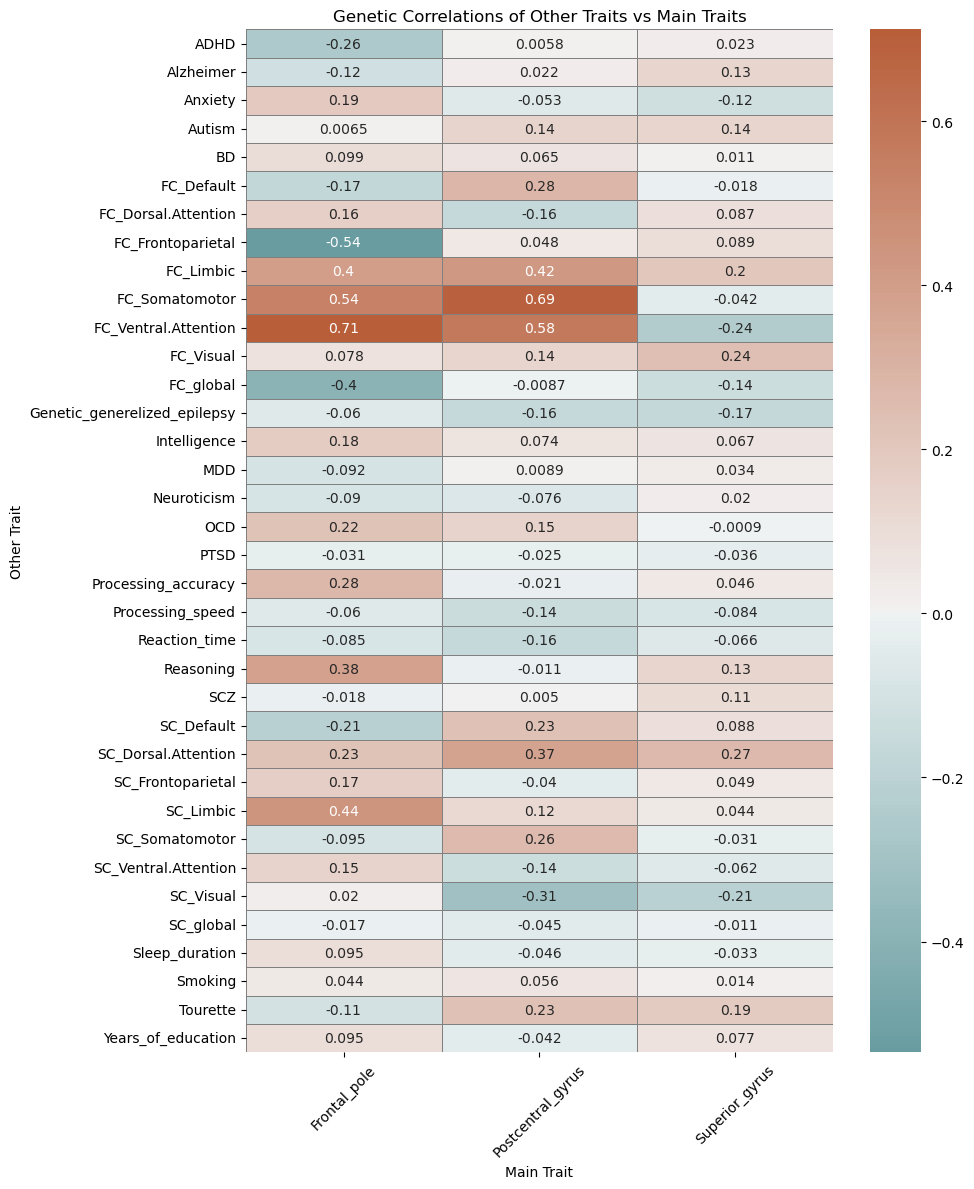

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load each result file
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

# Add column for main trait name
df_fp['MainTrait'] = 'Frontal_pole'
df_sg['MainTrait'] = 'Superior_gyrus'
df_pg['MainTrait'] = 'Postcentral_gyrus'

# Combine all dataframes
df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Pivot so rows = Trait (other traits), columns = MainTrait, values = GeneticCorrelation
corr_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='GeneticCorrelation')

# Optional: fill missing with 0 or NaN (choose your preference)
corr_matrix = corr_matrix.fillna(0)

cmap=sns.diverging_palette(200, 25, as_cmap=True)

# Plot heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, cmap=cmap, center=0, linewidths=0.5, linecolor='gray')
plt.title('Genetic Correlations of Other Traits vs Main Traits')
plt.ylabel('Other Trait')
plt.xlabel('Main Trait')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


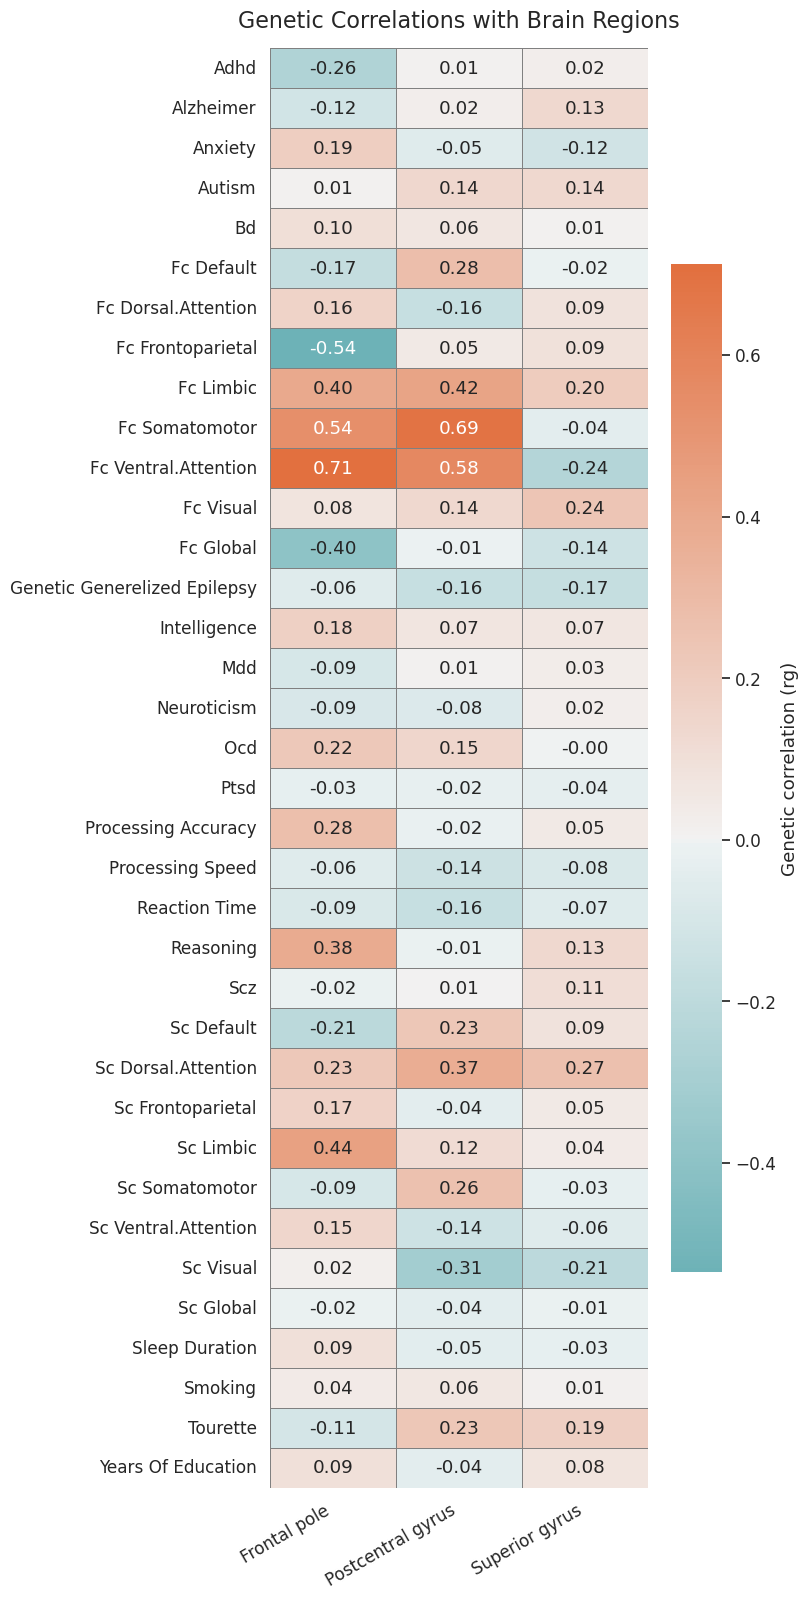

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

# Label origin
df_fp['MainTrait'] = 'Frontal pole'
df_sg['MainTrait'] = 'Superior gyrus'
df_pg['MainTrait'] = 'Postcentral gyrus'

# Combine
df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Pivot
corr_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='GeneticCorrelation')

# Improve trait name formatting (optional)
corr_matrix.index = corr_matrix.index.str.replace('_', ' ').str.title()

# Color palette
cmap = sns.diverging_palette(200, 25, s=80, l=60, as_cmap=True)

# Styling
plt.figure(figsize=(8, len(corr_matrix) * 0.45))
sns.set(style='whitegrid', font_scale=1.1)

# Create heatmap
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    linewidths=0.4,
    linecolor='gray',
    square=False,
    cbar_kws={"shrink": 0.7, "label": "Genetic correlation (rg)"}
)

# Labels and aesthetics
plt.title('Genetic Correlations with Brain Regions', fontsize=16, pad=15)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


In [10]:
import pandas as pd

# Load and label sources
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

df_fp['MainTrait'] = 'Frontal pole'
df_sg['MainTrait'] = 'Superior gyrus'
df_pg['MainTrait'] = 'Postcentral gyrus'

df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Pivot to matrix
corr_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='GeneticCorrelation')
corr_matrix.index = corr_matrix.index.str.replace('_', ' ').str.title()


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Load and combine as before
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

df_fp['MainTrait'] = 'Frontal pole'
df_sg['MainTrait'] = 'Superior gyrus'
df_pg['MainTrait'] = 'Ppecentral gyrus'

df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)
corr_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='GeneticCorrelation')
corr_matrix.index = corr_matrix.index.str.replace('_', ' ').str.title()

# --- CLUSTERING ---
# Cluster rows (traits)
row_linkage = linkage(pdist(corr_matrix.values), method='average')
row_order = leaves_list(row_linkage)


# Reorder matrix
corr_matrix_clustered = corr_matrix.iloc[row_order, col_order]

# --- PLOTLY ---
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix_clustered.values,
    x=corr_matrix_clustered.columns,
    y=corr_matrix_clustered.index,
    colorscale='BrBg',
#    zmin=-1, zmax=1,
    colorbar=dict(
        title='Genetic Correlation (rg)',
        titleside='right',
        ticks='outside',
        #tickvals=[-1, -0.5, 0, 0.5, 1],
        thickness=20,
        len=0.75,
        y=0.5,
        yanchor='middle'
    ),
    text=[[f"{val:.2f}" for val in row] for row in corr_matrix_clustered.values],
    texttemplate="%{text}",
    hoverinfo='text',
    showscale=True
))

fig.update_layout(
    title='Clustered Genetic Correlations',
    xaxis=dict(title='Main Trait', side='bottom'),
    yaxis=dict(title='Other Trait', autorange='reversed'),
    width=700,
    height=25 * len(corr_matrix_clustered) + 100,
    margin=dict(l=100, r=50, t=80, b=50),
    font=dict(size=12)
)

fig.show()

NameError: name 'pd' is not defined

In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Load and combine as before
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

df_fp['MainTrait'] = 'Frontal pole'
df_sg['MainTrait'] = 'Superior gyrus'
df_pg['MainTrait'] = 'Precentral gyrus'

df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)
corr_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='GeneticCorrelation')
corr_matrix.index = corr_matrix.index.str.replace('_', ' ').str.title()
corr_matrix = corr_matrix.fillna(1)

# --- CLUSTERING ---
# Cluster rows (traits)
row_linkage = linkage(pdist(corr_matrix.values), method='average')
row_order = leaves_list(row_linkage)

# Cluster columns (MainTrait)
col_linkage = linkage(pdist(corr_matrix.values.T), method='average')
col_order = leaves_list(col_linkage)

# Reorder matrix
corr_matrix_clustered = corr_matrix.iloc[row_order, col_order]

# --- PLOTLY ---
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix_clustered.values,
    x=corr_matrix_clustered.columns,
    y=corr_matrix_clustered.index,
    colorscale='BrBg_r',
    zmin=corr_matrix_clustered.values.min(), zmax=corr_matrix_clustered.values.max(),
    colorbar=dict(
        title='Genetic Correlation (rg)',
        titleside='right',
        ticks='outside',
       # tickvals=[-0.7, -0.5, -0.2, 0, 0.2, 0.5],
        thickness=20,
        len=0.75,
        y=0.5,
        yanchor='middle'
    ),
    text=[[f"{val:.2f}" for val in row] for row in corr_matrix_clustered.values],
    texttemplate="%{text}",
    hoverinfo='text',
    showscale=True
))

fig.update_layout(
    title='Clustered Genetic Correlations',
    xaxis=dict(title='Main Trait', side='bottom'),
    yaxis=dict(title='Other Trait', autorange='reversed'),
    width=700,
    height=25 * len(corr_matrix_clustered) + 100,
    margin=dict(l=100, r=50, t=80, b=50),
    font=dict(size=12)
)

fig.show()


In [12]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Load and combine as before
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

df_fp['MainTrait'] = 'Frontal pole'
df_sg['MainTrait'] = 'Superior gyrus'
df_pg['MainTrait'] = 'Precentral gyrus'

df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Pivot for correlation values AND p-values
corr_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='GeneticCorrelation')
pval_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='Pvalue')

corr_matrix.index = corr_matrix.index.str.replace('_', ' ').str.title()
pval_matrix.index = pval_matrix.index.str.replace('_', ' ').str.title()

corr_matrix = corr_matrix.fillna(1)
pval_matrix = pval_matrix.fillna(1)

# --- CLUSTERING ---
row_linkage = linkage(pdist(corr_matrix.values), method='average')
row_order = leaves_list(row_linkage)

col_linkage = linkage(pdist(corr_matrix.values.T), method='average')
col_order = leaves_list(col_linkage)

# Reorder both matrices
corr_matrix_clustered = corr_matrix.iloc[row_order, col_order]
pval_matrix_clustered = pval_matrix.iloc[row_order, col_order]

# Create text with correlation values and asterisks for p < 0.05
text_matrix = []
for i, row in enumerate(corr_matrix_clustered.values):
    text_row = []
    for j, val in enumerate(row):
        pval = pval_matrix_clustered.iloc[i, j]
        asterisk = '*' if pval < 0.05 else ''
        text_row.append(f"{val:.2f}{asterisk}")
    text_matrix.append(text_row)

# --- PLOTLY ---
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix_clustered.values,
    x=corr_matrix_clustered.columns,
    y=corr_matrix_clustered.index,
    colorscale='BrBg_r',
    zmin=corr_matrix_clustered.values.min(), 
    zmax=corr_matrix_clustered.values.max(),
    colorbar=dict(
        title='Genetic Correlation (rg)',
        titleside='right',
        ticks='outside',
        thickness=20,
        len=0.75,
        y=0.5,
        yanchor='middle'
    ),
    text=text_matrix,
    texttemplate="%{text}",
    hoverinfo='text',
    showscale=True
))

fig.update_layout(
    title='Clustered Genetic Correlations',
    xaxis=dict(title='Main Trait', side='bottom'),
    yaxis=dict(title='Other Trait', autorange='reversed'),
    width=700,
    height=25 * len(corr_matrix_clustered) + 100,
    margin=dict(l=100, r=50, t=80, b=50),
    font=dict(size=12)
)

fig.show()

In [18]:
df_all

,Trait,GeneticCorrelation,SE,Zscore,Pvalue,MainTrait
0,ADHD,-0.2550,0.2113,-1.2064,0.2277,Frontal pole
1,Alzheimer,-0.1203,0.1957,-0.6148,0.5387,Frontal pole
2,Anxiety,0.1919,0.5272,0.3641,0.7158,Frontal pole
3,Autism,0.0065,0.3402,0.0190,0.9848,Frontal pole
4,BD,0.0994,0.1701,0.5843,0.5590,Frontal pole
...,...,...,...,...,...,...
100,FC VAN,0.5754,0.2784,2.0667,0.0388,Precentral gyrus
101,FC Visual,0.1364,0.5361,0.2544,0.7992,Precentral gyrus
102,SFC frontal pole,-0.5466,0.6072,-0.9001,0.3681,Precentral gyrus
103,SFC supramarginal gyrus,-0.3198,0.2510,-1.2738,0.2027,Precentral gyrus


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Load data
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

# Preserve original trait order from the first file
trait_order = df_fp['Trait'].tolist()

df_fp['MainTrait'] = 'Frontal pole'
df_sg['MainTrait'] = 'Supramaginal gyrus'
df_pg['MainTrait'] = 'Precentral gyrus'

df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Pivot for correlation values AND p-values
corr_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='GeneticCorrelation')
pval_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='Pvalue')

# Reorder rows to match original CSV order
corr_matrix = corr_matrix.reindex(trait_order)
pval_matrix = pval_matrix.reindex(trait_order)

corr_matrix = corr_matrix.fillna(0)
pval_matrix = pval_matrix.fillna(0)

# Create text with correlation values and asterisks for p < 0.05
text_matrix = []
for i, row in enumerate(corr_matrix.values):
    text_row = []
    for j, val in enumerate(row):
        pval = pval_matrix.iloc[i, j]
        asterisk = '*' if pval < 0.05 else ''
        text_row.append(f"{val:.2f}{asterisk}")
    text_matrix.append(text_row)

# --- PLOTLY ---
fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.index,
    colorscale='curl', #BrBg_r
   # zmin=corr_matrix_clustered.values.min(), 
   # zmax=corr_matrix_clustered.values.max(),
    zmid=0,  # Center colorbar at 0
    colorbar=dict(
        title='Genetic Correlation (rg)',
        titleside='right',
        ticks='outside',
        thickness=20,
        len=0.75,
        y=0.5,
        yanchor='middle'
    ),
    text=text_matrix,
    texttemplate="%{text}",
    hoverinfo='text',
    showscale=True
))

fig.update_layout(
    xaxis=dict(title='', side='bottom'),
    yaxis=dict(title='', autorange='reversed'),
    width=700,
    height=25 * len(corr_matrix) + 100,
    margin=dict(l=100, r=50, t=80, b=50),
    font=dict(size=12)
)

fig.show()

In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Load data
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

# Preserve original trait order from the first file
trait_order = df_fp['Trait'].tolist()

df_fp['MainTrait'] = 'SFC frontal pole'
df_sg['MainTrait'] = 'SFC supramarginal gyrus'
df_pg['MainTrait'] = 'SFC precentral gyrus'

df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Pivot for correlation values AND p-values
corr_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='GeneticCorrelation')
pval_matrix = df_all.pivot(index='Trait', columns='MainTrait', values='Pvalue')

# Reorder rows to match original CSV order
corr_matrix = corr_matrix.reindex(trait_order)
pval_matrix = pval_matrix.reindex(trait_order)

corr_matrix = corr_matrix.fillna(0)
pval_matrix = pval_matrix.fillna(0)

# Create text and color matrix
text_matrix = []
color_matrix = np.array(corr_matrix.values, dtype=float)

for i, row in enumerate(corr_matrix.values):
    text_row = []
    for j, val in enumerate(row):
        pval = pval_matrix.iloc[i, j]
        
        # Check if this is a self-correlation (row and column trait match)
        if corr_matrix.index[i] == corr_matrix.columns[j]:
            text_row.append("")  # Empty text for self-correlations
            color_matrix[i, j] = np.nan  # Will appear grey
        else:
            asterisk = '*' if pval < 0.05 else ''
            text_row.append(f"{val:.2f}{asterisk}")
    text_matrix.append(text_row)

# --- PLOTLY ---
fig = go.Figure(data=go.Heatmap(
    z=color_matrix,
    x=corr_matrix.columns,
    y=corr_matrix.index,
    colorscale='curl',
    zmid=0,
    colorbar=dict(
        title='Genetic Correlation (rg)',
        titleside='right',
        ticks='outside',
        thickness=20,
        len=0.75,
        y=0.5,
        yanchor='middle'
    ),
    text=text_matrix,
    texttemplate="%{text}",
    hoverinfo='text',
    showscale=True
))

fig.update_layout(
    xaxis=dict(title='', side='bottom'),
    yaxis=dict(title='', autorange='reversed'),
    width=680,
    height=20 * len(corr_matrix) + 100,
    margin=dict(l=100, r=50, t=80, b=50),
    font=dict(size=11)
)
fig.write_image('ldsc.png')
fig.show()

In [28]:
import pandas as pd
import plotly.express as px

# Load data as before
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

# Prepare each dataframe
def prep_df(df, main_trait_name):
    df = df.copy()
    df['OtherTrait'] = df['Trait'].str.replace('_', ' ').str.title()
    # Add asterisk if p-value < 0.05
    df['Significant'] = df['Pvalue'] < 0.05
    df['OtherTrait_label'] = df['OtherTrait'] + df['Significant'].apply(lambda x: '*' if x else '')
    df['MainTrait'] = main_trait_name
    return df[['OtherTrait_label', 'GeneticCorrelation', 'MainTrait', 'Pvalue', 'Significant']]

df_fp = prep_df(df_fp, 'Frontal Pole')
df_sg = prep_df(df_sg, 'Superior Gyrus')
df_pg = prep_df(df_pg, 'Precentral Gyrus')

# Combine
df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Plot a separate scatter plot for each main trait
for main_trait in df_all['MainTrait'].unique():
    dfi = df_all[df_all['MainTrait'] == main_trait]
    
    fig = px.scatter(
        dfi,
        y='OtherTrait_label',
        x='GeneticCorrelation',
        title=f'Genetic Correlations with {main_trait}',
        labels={'OtherTrait_label': 'Other Trait', 'GeneticCorrelation': 'Genetic Correlation (rg)'},
        range_x=[-1, 1],
        color='Significant',
        color_discrete_map={True: 'darkred', False: 'royalblue'}
    )
    fig.update_traces(marker=dict(size=7))
    fig.update_layout(
        yaxis=dict(autorange="reversed"),
        xaxis=dict(zeroline=True, zerolinewidth=2, zerolinecolor='gray'),
        margin=dict(l=150, r=40, t=50, b=50),
        height=500,
        width=800,
        showlegend=True
    )
    fig.show()

In [30]:
import pandas as pd
import plotly.graph_objects as go

# Load data as before
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

# Prepare each dataframe
def prep_df(df, main_trait_name):
    df = df.copy()
    df['OtherTrait'] = df['Trait'].str.replace('_', ' ').str.title()
    # Add asterisk if p-value < 0.05
    df['Significant'] = df['Pvalue'] < 0.05
    df['OtherTrait_label'] = df['OtherTrait'] + df['Significant'].apply(lambda x: '*' if x else '')
    df['MainTrait'] = main_trait_name
    return df[['OtherTrait_label', 'GeneticCorrelation', 'MainTrait', 'Pvalue', 'Significant', 'SE']]

df_fp = prep_df(df_fp, 'Frontal Pole')
df_sg = prep_df(df_sg, 'Superior Gyrus')
df_pg = prep_df(df_pg, 'Precentral Gyrus')

# Combine
df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Plot a separate scatter plot for each main trait with error bars
for main_trait in df_all['MainTrait'].unique():
    dfi = df_all[df_all['MainTrait'] == main_trait].sort_values('OtherTrait_label')
    
    fig = go.Figure()
    
    # Add scatter with error bars (95% CI = 1.96 * SE)
    fig.add_trace(go.Scatter(
        y=dfi['OtherTrait_label'],
        x=dfi['GeneticCorrelation'],
        error_x=dict(
            type='data',
            array=1.96 * dfi['SE'],
            visible=True
        ),
        mode='markers',
        marker=dict(
            size=7,
            color=['darkred' if sig else 'royalblue' for sig in dfi['Significant']]
        ),
        name=main_trait
    ))
    
    fig.update_layout(
        title=f'Genetic Correlations with {main_trait}',
        xaxis=dict(
            title='Genetic Correlation (rg)',
            zeroline=True,
            zerolinewidth=2,
            zerolinecolor='gray',
            range=[-1, 1]
        ),
        yaxis=dict(
            title='Other Trait',
            autorange='reversed'
        ),
        margin=dict(l=150, r=40, t=50, b=50),
        height=500,
        width=800,
    )
    fig.show()

In [8]:
import pandas as pd
import plotly.express as px

# Load data as before
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

# Prepare each dataframe
def prep_df(df, main_trait_name):
    df = df.copy()
    df['OtherTrait'] = df['Trait'].str.replace('_', ' ').str.title()
    # Add asterisk if p-value < 0.05
    df['Significant'] = df['Pvalue'] < 0.05
    df['OtherTrait_label'] = df['OtherTrait'] + df['Significant'].apply(lambda x: '*' if x else '')
    df['MainTrait'] = main_trait_name
    return df[['OtherTrait_label', 'GeneticCorrelation', 'MainTrait', 'Pvalue', 'Significant']]

df_fp = prep_df(df_fp, 'Frontal Pole')
df_sg = prep_df(df_sg, 'Superior Gyrus')
df_pg = prep_df(df_pg, 'Precentral Gyrus')

# Combine
df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Plot a separate scatter plot for each main trait
for main_trait in df_all['MainTrait'].unique():
    dfi = df_all[df_all['MainTrait'] == main_trait]
    
    fig = px.scatter(
        dfi,
        y='OtherTrait_label',
        x='GeneticCorrelation',
        title=f'Genetic Correlations with {main_trait}',
        labels={'OtherTrait_label': 'Other Trait', 'GeneticCorrelation': 'Genetic Correlation (rg)'},
        range_x=[-1, 1],
        color='Significant',
        color_discrete_map={True: 'darkred', False: 'royalblue'}
    )
    fig.update_traces(marker=dict(size=7))
    fig.update_layout(
        yaxis=dict(autorange="reversed"),
        xaxis=dict(zeroline=True, zerolinewidth=2, zerolinecolor='gray'),
        margin=dict(l=150, r=40, t=50, b=50),
        height=500,
        width=800,
        showlegend=True
    )
    fig.show()

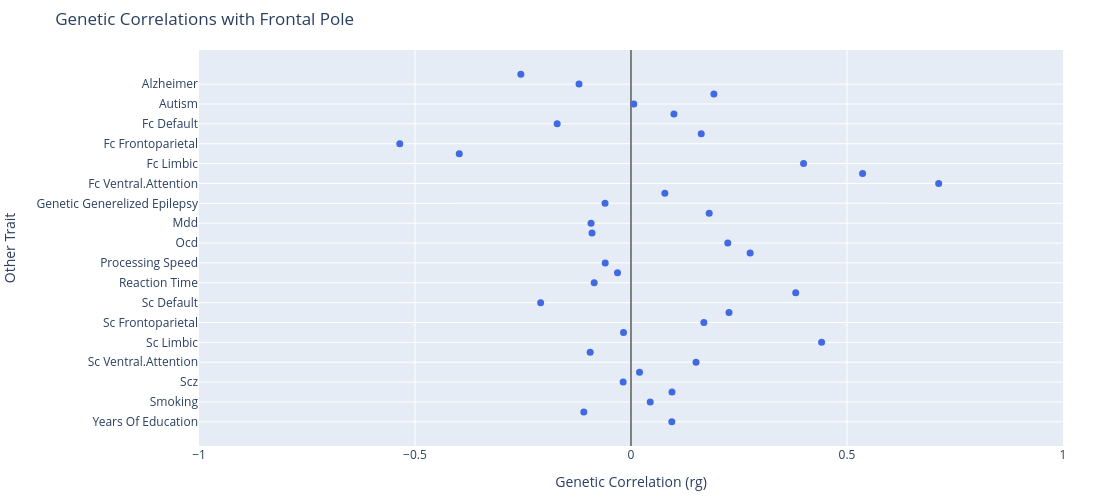

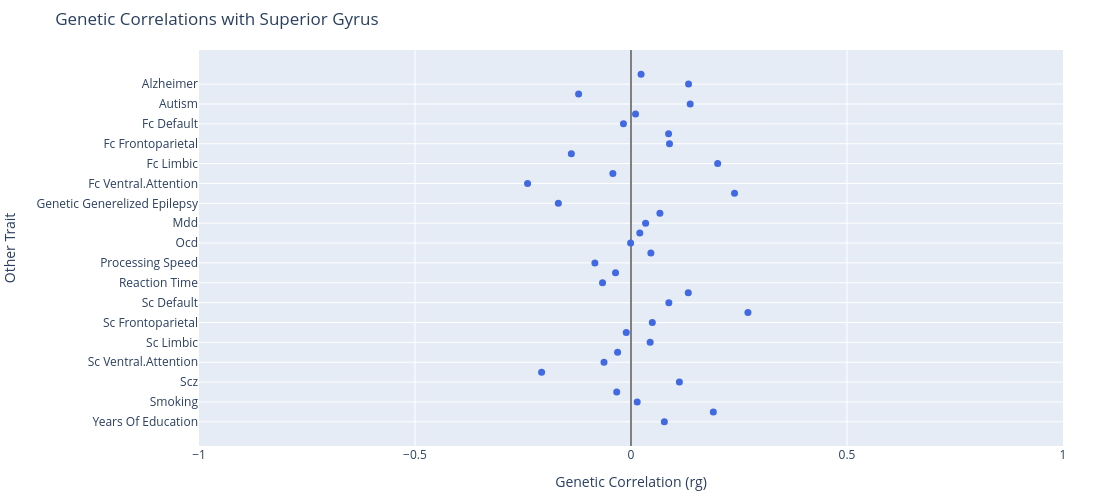

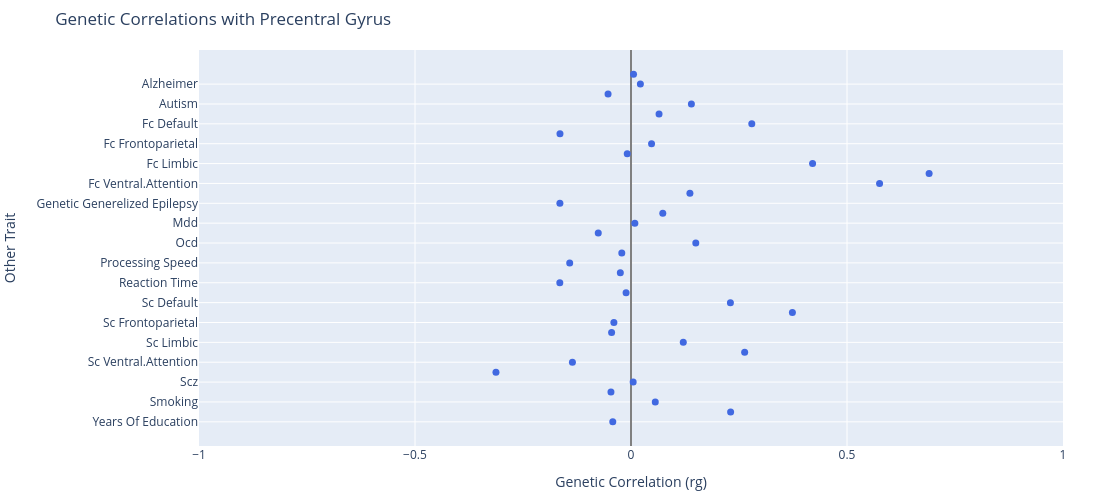

In [37]:
import pandas as pd
import plotly.express as px

# Load data as before
df_fp = pd.read_csv('results_FP.tsv', sep='\t')
df_sg = pd.read_csv('results_SG.tsv', sep='\t')
df_pg = pd.read_csv('results_PG.tsv', sep='\t')

# Prepare each dataframe
def prep_df(df, main_trait_name):
    df = df.copy()
    df['OtherTrait'] = df['Trait'].str.replace('_', ' ').str.title()
    df['MainTrait'] = main_trait_name
    return df[['OtherTrait', 'GeneticCorrelation', 'MainTrait']]

df_fp = prep_df(df_fp, 'Frontal Pole')
df_sg = prep_df(df_sg, 'Superior Gyrus')
df_pg = prep_df(df_pg, 'Precentral Gyrus')

# Combine
df_all = pd.concat([df_fp, df_sg, df_pg], ignore_index=True)

# Plot a separate scatter plot for each main trait, vertical orientation
for main_trait in df_all['MainTrait'].unique():
    dfi = df_all[df_all['MainTrait'] == main_trait]
    
    fig = px.scatter(
        dfi,
        y='OtherTrait',
        x='GeneticCorrelation',
        title=f'Genetic Correlations with {main_trait}',
        labels={'OtherTrait': 'Other Trait', 'GeneticCorrelation': 'Genetic Correlation (rg)'},
        range_x=[-1,1]
    )
    fig.update_traces(marker=dict(size=7, color='royalblue'))
    fig.update_layout(
        yaxis=dict(autorange="reversed"),  # so traits go top to bottom
        xaxis=dict(zeroline=True, zerolinewidth=2, zerolinecolor='gray'),
        margin=dict(l=150, r=40, t=50, b=50),
        height=500,
        width=800,
    )
    fig.show()
